 # Probe Analysis

 Phoneme identity + L1 accent linear probing across Whisper encoder layers.

 Loads per-model JSON files (new convention: `{probe}_{model_key}_{split}.json`).

In [25]:
# ── Config ────────────────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

SPLIT       = "scripted"
RESULTS_DIR = Path("results/probe_analysis")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Map model key → display label / colour
MODEL_STYLES = {
    "baseline":      {"label": "Baseline (frozen)", "color": "#2687ee", "marker": "o"},
    "no_aux": {"label": "Naive LoRA FT",     "color": "#f28e2b", "marker": "s"},
    "ctc_aux_l3":       {"label": "CTC Aux",            "color": "#3db32d", "marker": "^"},
    "feat_aux":      {"label": "Feat Aux",           "color": "#e15759", "marker": "D"},
    "feat_aux0p3":      {"label": "Feat Aux (0.3)",           "color": "#8D1461", "marker": "X"},
}

PROBE_DIRS = {
    "phoneme": Path("results/phoneme_probe"),
    "accent":  Path("results/accent_probe"),
    "speaker": Path("results/speaker_probe"),
}


In [26]:
# ── Loader ────────────────────────────────────────────────────────────────────
def load_probe(probe, model_key, split=SPLIT):
    """Load a per-model probe JSON. Returns {} if file not found."""
    path = PROBE_DIRS[probe] / f"{probe}_probe_{model_key}_{split}.json"
    if not path.exists():
        print(f"  [missing] {path}")
        return {}
    with open(path) as f:
        return json.load(f)

def discover_layers(probe_data):
    """Return sorted integer layer indices from any loaded probe dict."""
    return sorted(int(k) for k in probe_data.keys())

# Load all available probes for all model keys
probes = {probe: {} for probe in PROBE_DIRS}
for probe in PROBE_DIRS:
    for key in MODEL_STYLES:
        data = load_probe(probe, key)
        if data:
            probes[probe][key] = data

print("Loaded probes:")
for probe, models in probes.items():
    print(f"  {probe}: {list(models.keys())}")

# Derive layer list from first available result
_first = next(
    (data for p in probes.values() for data in p.values() if data),
    {}
)
LAYERS = discover_layers(_first)
print(f"Layers: {LAYERS}")


  [missing] results/accent_probe/accent_probe_feat_aux0p3_scripted.json
  [missing] results/speaker_probe/speaker_probe_baseline_scripted.json
  [missing] results/speaker_probe/speaker_probe_no_aux_scripted.json
  [missing] results/speaker_probe/speaker_probe_ctc_aux_l3_scripted.json
  [missing] results/speaker_probe/speaker_probe_feat_aux_scripted.json
  [missing] results/speaker_probe/speaker_probe_feat_aux0p3_scripted.json
Loaded probes:
  phoneme: ['baseline', 'no_aux', 'ctc_aux_l3', 'feat_aux', 'feat_aux0p3']
  accent: ['baseline', 'no_aux', 'ctc_aux_l3', 'feat_aux']
  speaker: []
Layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [27]:
# ── Metric extractor ──────────────────────────────────────────────────────────
def get_metric(probe_data, layers, metric="accuracy", sub_key=None):
    """
    Extract a per-layer metric from a probe result dict.
    sub_key: optional nested key (e.g. "global" for accent probe).
    Returns np.array of floats (nan where missing).
    """
    out = []
    for li in layers:
        entry = probe_data.get(str(li), {})
        if sub_key:
            entry = entry.get(sub_key, {})
        out.append(float(entry.get(metric, float("nan"))))
    return np.array(out)

def get_chance(probe_data, layer):
    """Get chance accuracy from a probe dict at a given layer."""
    entry = probe_data.get(str(layer), {})
    # accent probe stores chance inside "global"
    return (entry.get("chance_accuracy")
            or entry.get("global", {}).get("chance_accuracy"))

# Helper: which sub_key to use for a given probe
PROBE_SUBKEY = {"phoneme": None, "accent": "global", "speaker": None}


In [28]:
# ── Shared plot helpers ───────────────────────────────────────────────────────
def plot_probe_lines(ax, probe, metric="accuracy", layers=LAYERS):
    """Plot one line per available model for a given probe + metric."""
    for key, style in MODEL_STYLES.items():
        data = probes[probe].get(key)
        if data is None:
            continue
        vals = get_metric(data, layers, metric, sub_key=PROBE_SUBKEY[probe])
        ax.plot(layers, vals,
                marker=style["marker"], color=style["color"],
                label=style["label"], linewidth=2, markersize=5)

    # Chance line from first available model
    for key in MODEL_STYLES:
        data = probes[probe].get(key)
        if data:
            chance = get_chance(data, layers[0])
            if chance:
                ax.axhline(chance, linestyle="--", color="gray", alpha=0.45,
                           label=f"Chance ({chance:.3f})")
            break

    ax.set_xticks(layers)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Encoder layer", fontsize=11)
    ax.legend(fontsize=9)


 ## 1 — Phoneme Probe

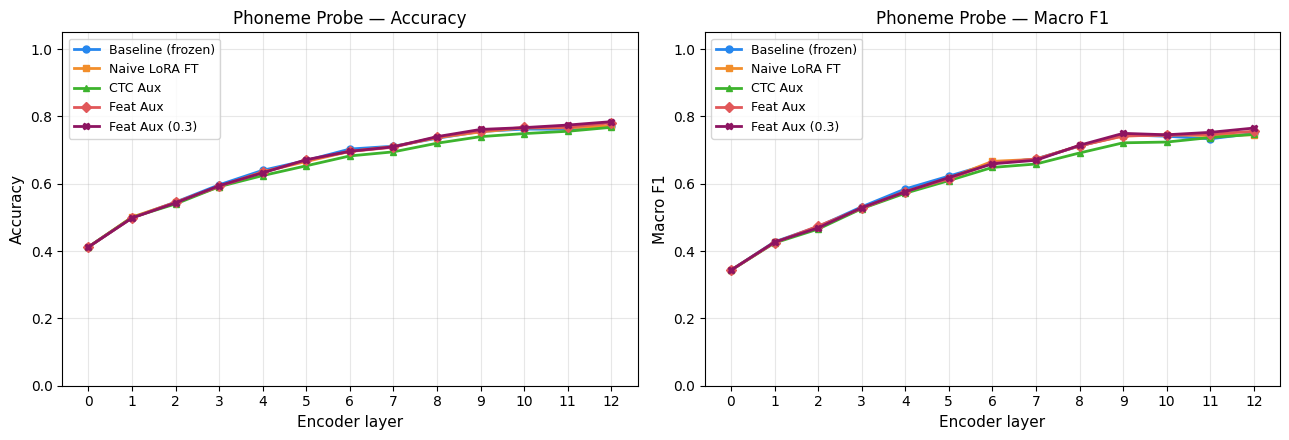

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (metric, ylabel) in zip(axes, [("accuracy", "Accuracy"), ("macro_f1", "Macro F1")]):
    plot_probe_lines(ax, "phoneme", metric=metric)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"Phoneme Probe — {ylabel}", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "phoneme_probe_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()


 ## 2 — Accent Probe

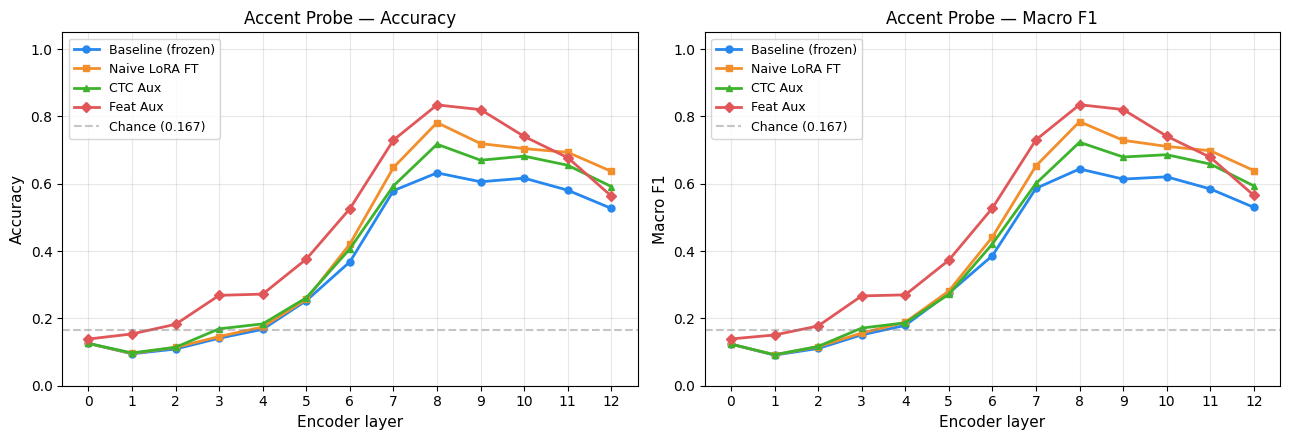

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (metric, ylabel) in zip(axes, [("accuracy", "Accuracy"), ("macro_f1", "Macro F1")]):
    plot_probe_lines(ax, "accent", metric=metric)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"Accent Probe — {ylabel}", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "accent_probe_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()


 ## 3 — Speaker Probe

/tmp/ipykernel_3286330/1190496316.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


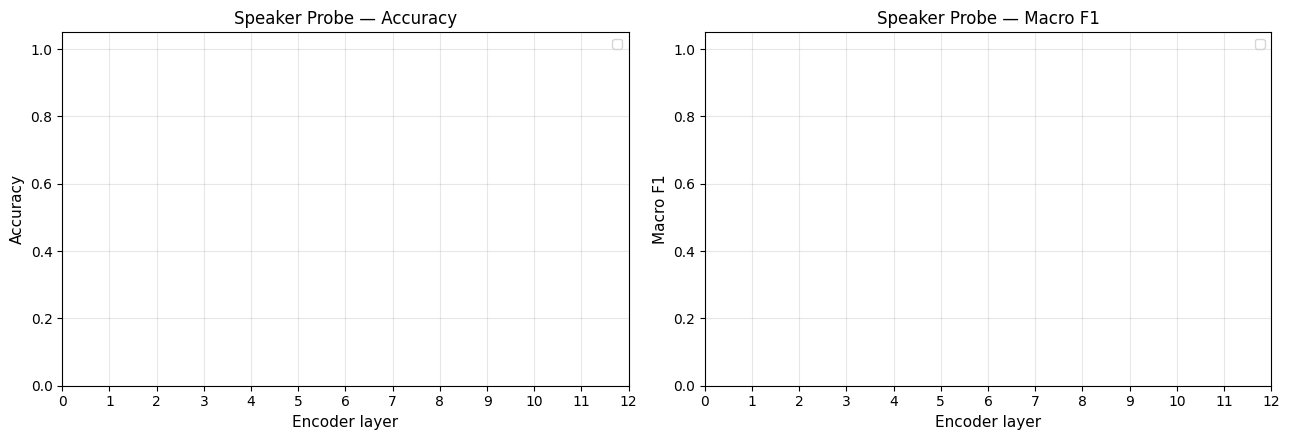

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (metric, ylabel) in zip(axes, [("accuracy", "Accuracy"), ("macro_f1", "Macro F1")]):
    plot_probe_lines(ax, "speaker", metric=metric)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f"Speaker Probe — {ylabel}", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "speaker_probe_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()


 ## 4 — Phoneme vs Accent vs Speaker per Model (key thesis figure)

 Does fine-tuning preserve phoneme decodability while reducing accent decodability?

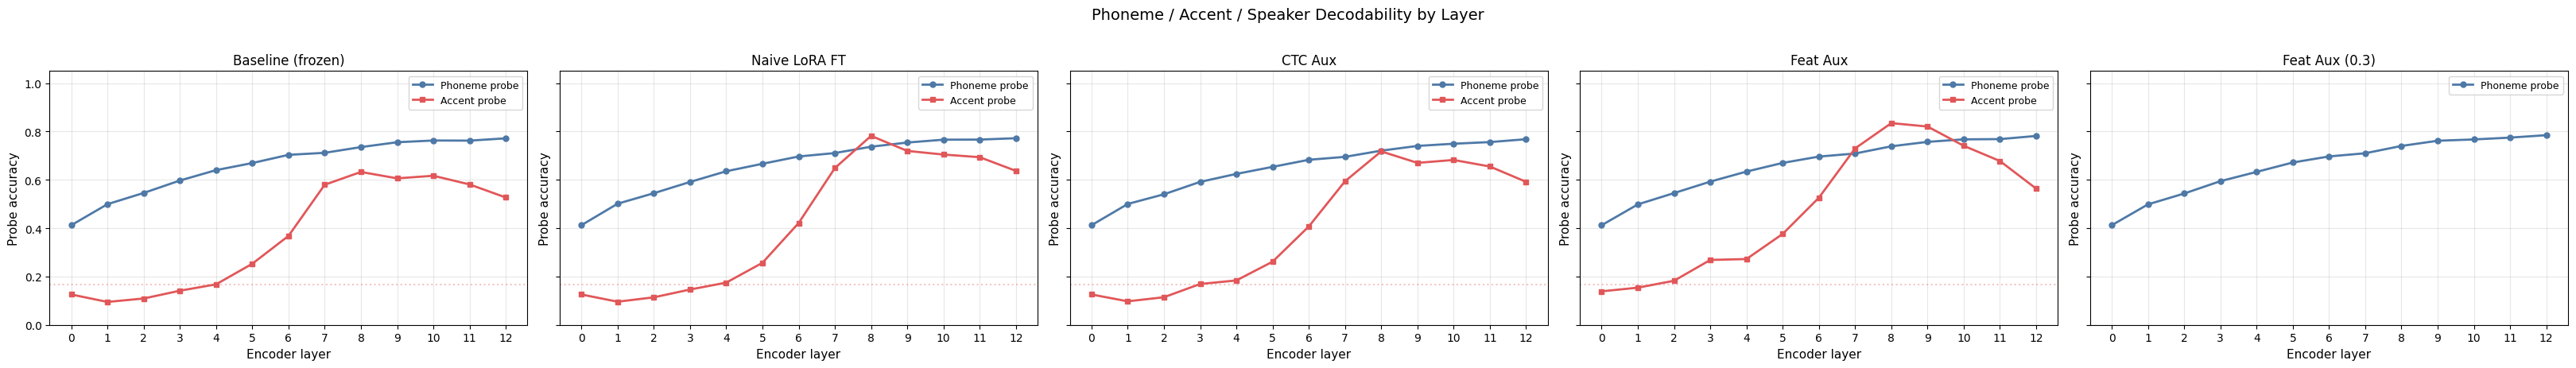

In [32]:
active_models = [k for k in MODEL_STYLES if any(probes[p].get(k) for p in PROBE_DIRS)]
fig, axes = plt.subplots(1, len(active_models),
                          figsize=(6.5 * len(active_models), 4.5), sharey=True)
if len(active_models) == 1:
    axes = [axes]

PROBE_PLOT_STYLES = {
    "phoneme": {"color": "#4e79a7", "marker": "o", "label": "Phoneme probe"},
    "accent":  {"color": "#e15759", "marker": "s", "label": "Accent probe"},
    "speaker": {"color": "#76b7b2", "marker": "^", "label": "Speaker probe"},
}

for ax, key in zip(axes, active_models):
    for probe, ps in PROBE_PLOT_STYLES.items():
        data = probes[probe].get(key)
        if data is None:
            continue
        vals = get_metric(data, LAYERS, "accuracy", sub_key=PROBE_SUBKEY[probe])
        ax.plot(LAYERS, vals, marker=ps["marker"], color=ps["color"],
                label=ps["label"], linewidth=2, markersize=5)
        chance = get_chance(data, LAYERS[0])
        if chance:
            ax.axhline(chance, linestyle=":", color=ps["color"], alpha=0.35)

    ax.set_title(MODEL_STYLES[key]["label"], fontsize=12)
    ax.set_xlabel("Encoder layer", fontsize=11)
    ax.set_ylabel("Probe accuracy", fontsize=11)
    ax.set_xticks(LAYERS)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle("Phoneme / Accent / Speaker Decodability by Layer", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "phoneme_vs_accent_vs_speaker_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()


 ## 5 — Delta plots: effect of fine-tuning relative to baseline

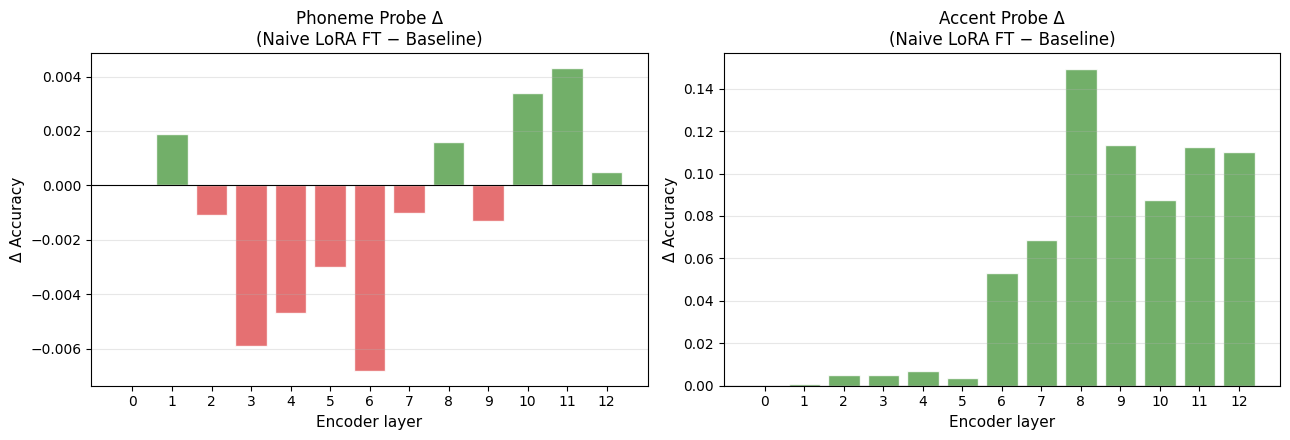

Saved: results/probe_analysis/probe_delta_no_aux_by_layer.png


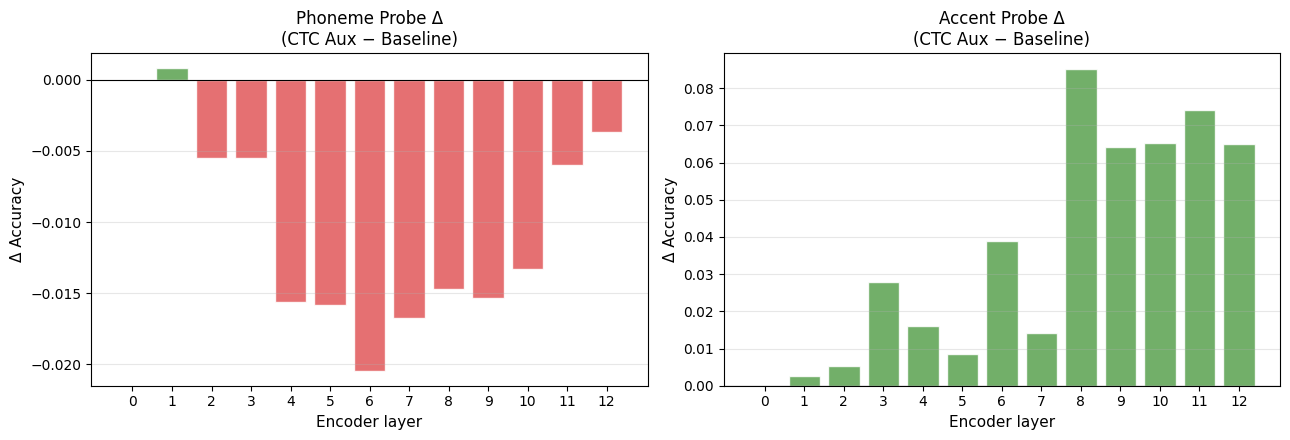

Saved: results/probe_analysis/probe_delta_ctc_aux_l3_by_layer.png


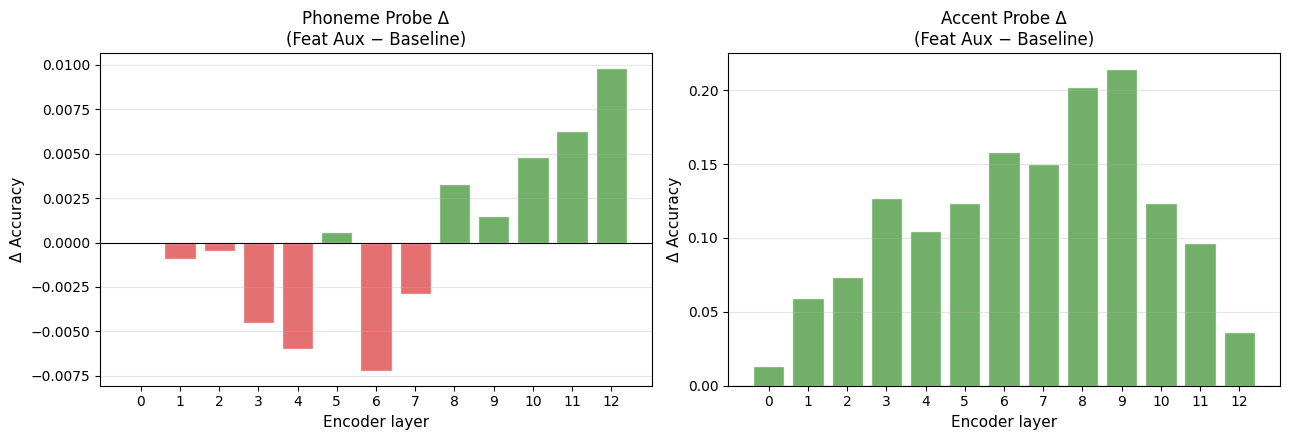

Saved: results/probe_analysis/probe_delta_feat_aux_by_layer.png


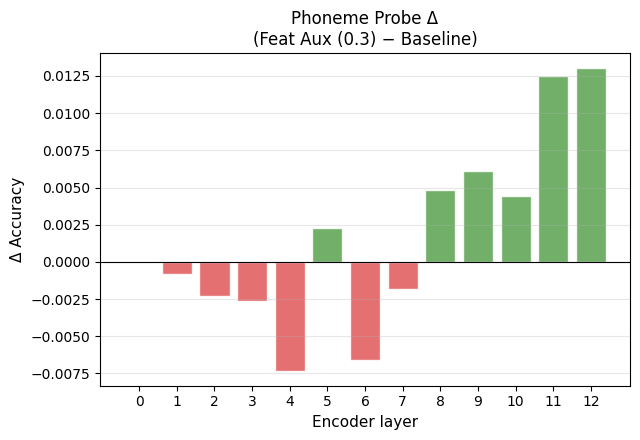

Saved: results/probe_analysis/probe_delta_feat_aux0p3_by_layer.png


In [33]:
DELTA_MODELS = [k for k in MODEL_STYLES if k != "baseline" and any(probes[p].get(k) for p in PROBE_DIRS)]

for ft_key in DELTA_MODELS:
    ft_label = MODEL_STYLES[ft_key]["label"]
    n_probes = sum(1 for p in PROBE_DIRS if probes[p].get("baseline") and probes[p].get(ft_key))
    if n_probes == 0:
        print(f"No baseline/ft pair for {ft_key}")
        continue

    probe_pairs = [(p, probes[p]) for p in PROBE_DIRS
                   if probes[p].get("baseline") and probes[p].get(ft_key)]
    fig, axes = plt.subplots(1, len(probe_pairs), figsize=(6.5 * len(probe_pairs), 4.5))
    if len(probe_pairs) == 1:
        axes = [axes]

    for ax, (probe, pdata) in zip(axes, probe_pairs):
        base = get_metric(pdata["baseline"], LAYERS, "accuracy", sub_key=PROBE_SUBKEY[probe])
        ft   = get_metric(pdata[ft_key],   LAYERS, "accuracy", sub_key=PROBE_SUBKEY[probe])
        delta = ft - base
        colors = ["#59a14f" if d >= 0 else "#e15759" for d in delta]
        ax.bar(LAYERS, delta, color=colors, alpha=0.85, edgecolor="white")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Encoder layer", fontsize=11)
        ax.set_ylabel("Δ Accuracy", fontsize=11)
        ax.set_title(f"{probe.capitalize()} Probe Δ\n({ft_label} − Baseline)", fontsize=12)
        ax.set_xticks(LAYERS)
        ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    fname = RESULTS_DIR / f"probe_delta_{ft_key}_by_layer.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


 ## 6 — Accent-beyond-speaker Δ (if available)

 Positive = layer encodes group-level accent beyond individual speaker cues.

In [34]:
has_abs = any(
    probes["speaker"].get(k, {}).get(str(LAYERS[0]), {}).get("accent_beyond_speaker") is not None
    for k in MODEL_STYLES
)
print(f"accent_beyond_speaker available: {has_abs}")

if has_abs:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for key, style in MODEL_STYLES.items():
        data = probes["speaker"].get(key)
        if data is None:
            continue
        vals = np.array([
            float(data.get(str(li), {}).get("accent_beyond_speaker", float("nan")))
            for li in LAYERS
        ])
        if np.all(np.isnan(vals)):
            continue
        ax.plot(LAYERS, vals, marker=style["marker"], color=style["color"],
                label=style["label"], linewidth=2, markersize=5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Encoder layer", fontsize=11)
    ax.set_ylabel("Accent-beyond-speaker Δ", fontsize=11)
    ax.set_title("Accent decodability not explained by speaker identity", fontsize=12)
    ax.set_xticks(LAYERS)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "accent_beyond_speaker_by_layer.png", dpi=150, bbox_inches="tight")
    plt.show()


accent_beyond_speaker available: False


 ## 7 — Within-phoneme accent probe (if available)

 Per-phoneme accent decodability: which phones carry the most accent signal?

Within-phoneme results available: True


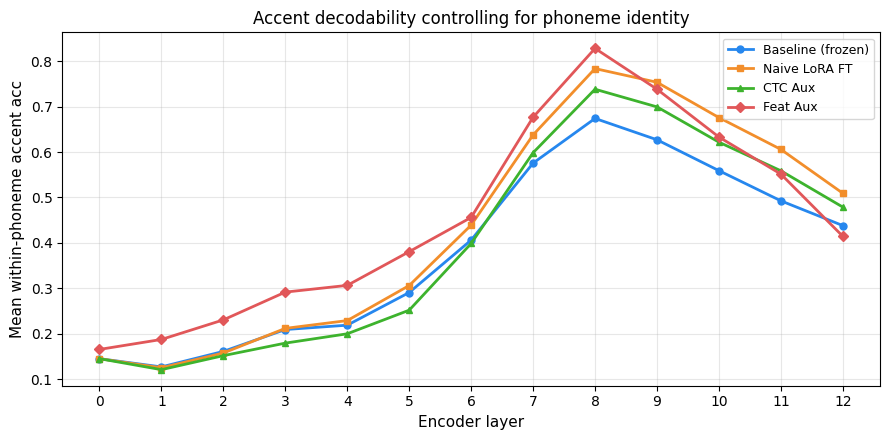


[baseline] Top 10 phones by accent decodability (layer 12):
  D       0.501
  R       0.480
  TH      0.456
  L       0.451
  T       0.417
  AE      0.406
  S       0.355

[no_aux] Top 10 phones by accent decodability (layer 12):
  D       0.565
  L       0.544
  TH      0.507
  T       0.503
  R       0.500
  AE      0.484
  S       0.462

[ctc_aux_l3] Top 10 phones by accent decodability (layer 12):
  D       0.529
  TH      0.500
  L       0.489
  R       0.485
  T       0.479
  AE      0.463
  S       0.407

[feat_aux] Top 10 phones by accent decodability (layer 12):
  T       0.464
  D       0.458
  S       0.441
  R       0.441
  AE      0.382
  L       0.376
  TH      0.341


In [35]:
sample_layer = str(LAYERS[-1])
has_wp = any(
    "within_phoneme" in probes["accent"].get(k, {}).get(sample_layer, {})
    for k in MODEL_STYLES
)
print(f"Within-phoneme results available: {has_wp}")

if has_wp:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for key, style in MODEL_STYLES.items():
        data = probes["accent"].get(key)
        if data is None:
            continue
        wp_accs = [
            float(data.get(str(li), {}).get("mean_within_phoneme_acc", float("nan")))
            for li in LAYERS
        ]
        ax.plot(LAYERS, wp_accs, marker=style["marker"], color=style["color"],
                label=style["label"], linewidth=2, markersize=5)
    ax.set_xlabel("Encoder layer", fontsize=11)
    ax.set_ylabel("Mean within-phoneme accent acc", fontsize=11)
    ax.set_title("Accent decodability controlling for phoneme identity", fontsize=12)
    ax.set_xticks(LAYERS); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "within_phoneme_accent_by_layer.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Top phones per model at last layer
    for key in MODEL_STYLES:
        wp_data = probes["accent"].get(key, {}).get(sample_layer, {}).get("within_phoneme", {})
        if not wp_data:
            continue
        phone_accs = {ph: v["accuracy"] for ph, v in wp_data.items()
                      if not np.isnan(float(v.get("accuracy", float("nan"))))}
        top = sorted(phone_accs.items(), key=lambda x: -x[1])[:10]
        print(f"\n[{key}] Top 10 phones by accent decodability (layer {sample_layer}):")
        for ph, acc in top:
            print(f"  {ph:6s}  {acc:.3f}")


 ## 8 — Numerical summary

In [36]:
rows = []
for key in MODEL_STYLES:
    for li in LAYERS:
        row = {"model": key, "layer": li}
        for probe in PROBE_DIRS:
            data = probes[probe].get(key, {}).get(str(li), {})
            sub  = data.get(PROBE_SUBKEY[probe] or "", data) if PROBE_SUBKEY[probe] else data
            row[f"{probe}_acc"] = float(sub.get("accuracy",  float("nan")))
            row[f"{probe}_f1"]  = float(sub.get("macro_f1", float("nan")))
        rows.append(row)

df = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.3f}".format)
display(df)
df.to_csv(RESULTS_DIR / "probe_summary.csv", index=False)
print(f"Saved: {RESULTS_DIR / 'probe_summary.csv'}")

,model,layer,phoneme_acc,phoneme_f1,accent_acc,accent_f1,speaker_acc,speaker_f1
0,baseline,0,0.412,0.343,0.126,0.124,NaN,NaN
1,baseline,1,0.499,0.428,0.095,0.091,NaN,NaN
2,baseline,2,0.546,0.473,0.109,0.111,NaN,NaN
3,baseline,3,0.597,0.532,0.141,0.151,NaN,NaN
4,baseline,4,0.640,0.585,0.168,0.179,NaN,NaN
...,...,...,...,...,...,...,...,...
60,feat_aux0p3,8,0.740,0.714,NaN,NaN,NaN,NaN
61,feat_aux0p3,9,0.762,0.750,NaN,NaN,NaN,NaN
62,feat_aux0p3,10,0.767,0.746,NaN,NaN,NaN,NaN
63,feat_aux0p3,11,0.775,0.753,NaN,NaN,NaN,NaN


Saved: results/probe_analysis/probe_summary.csv
